<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_05_reg_multivariada_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Regresión multivariada

Supongamos que tenemos un conjunto de características $X = X_1, X_2,\ldots,X_j,\ldots,X_n$ para realizar una predicción $y$ con valores esperados $\hat{y}$.

Cada $X_j$ puede escribirse como:

$X_1 = x_1^{(1)},x_1^{(2)},x_1^{(3)},\ldots,x_1^{(m)}$,

$X_2 = x_2^{(1)},x_2^{(2)},x_2^{(3)},\ldots,x_2^{(m)}$,

.

.

.

$X_n = x_n^{(1)},x_n^{(2)},x_n^{(3)},\ldots,x_n^{(m)}$.

Siendo $n$ el número de características y $m$ el número de datos,
$\hat{y} = \hat{y}^{(1)},\hat{y}^{(2)},\ldots,\hat{y}^{(m)}$ el conjunto de valores etiquetados, y
$y = y^{(1)},y^{(2)},\ldots,y^{(m)}$ los valores predichos por un modelo.

Lo anterior puede resumirse como:

| Training | $\hat{y}$ | $X_1$ | $X_2$ | . | . | . | . | $X_n$ |
|--------|--------|------|------|---|---|---|---|------|
| 1 | $\hat{y}^{(1)}$ | $x_1^{(1)}$ | $x_2^{(1)}$ | . | . | . | . | $x_n^{(1)}$ |
| 2 | $\hat{y}^{(2)}$ | $x_1^{(2)}$ | $x_2^{(2)}$ | . | . | . | . | $x_n^{(2)}$ |
| . | . | . | . | . | . | . | . | . |
| . | . | . | . | . | . | . | . | . |
| . | . | . | . | . | . | . | . | . |
| m | $\hat{y}^{(m)}$ | $x_1^{(m)}$ | $x_2^{(m)}$ | . | . | . | . | $x_n^{(m)}$ |

y el modelo puede ajustarse como sigue:

Para un solo dato de entrenamiento tenemos que:

\begin{equation}
y = h(\theta_0,\theta_1,\theta_2,\ldots,\theta_n) = \theta_0 + \theta_1 x_1+\theta_2 x_2 + \theta_3 x_3 + \ldots + \theta_n x_n
\end{equation}

\begin{equation}
h_{\Theta}(x) =
[\theta_0,\theta_1,\ldots,\theta_n]
\begin{bmatrix}
1\\
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix}
= \Theta^T X
\end{equation}

Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,\ldots,\theta_n]$ una matriz $1 \times (n+1)$ y

\begin{equation}
X =
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1\\
x_1^{(1)} & x_1^{(2)} & x_1^{(3)} & \cdots & x_1^{(m)}\\
x_2^{(1)} & x_2^{(2)} & x_2^{(3)} & \cdots & x_2^{(m)}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
x_n^{(1)} & x_n^{(2)} & x_n^{(3)} & \cdots & x_n^{(m)}
\end{bmatrix}_{(n+1)\times m}
\end{equation}

luego,

\begin{equation}
h = \Theta^T X
\end{equation}

con dimensión $1\times m$.

La anterior ecuación es un hiperplano en $\mathbb{R}^n$. Nótese que, en caso de tener una sola característica, la ecuación puede analizarse según lo visto en la sesión de regresión lineal.

Para la optimización, vamos a definir la función de coste $J(\theta_0,\theta_1,\theta_2,\ldots,\theta_n)$ como la función asociada a la mínima distancia entre los valores predichos y los valores esperados, según la métrica euclidiana.

- Métrica euclidiana

\begin{equation}
J(\theta_0,\theta_1,\theta_2,\ldots,\theta_n)=\frac{1}{2m} \sum_{i=1}^m \left( h_{\Theta}(x^{(i)})-\hat{y}^{(i)}\right)^2
\end{equation}

Otras métricas pueden definirse como se muestra en la siguiente referencia: [Metricas](https://jmlb.github.io/flashcards/2018/04/21/list_cost_functions_fo_neuralnets/).

Nuestro objetivo será encontrar los valores
$\Theta = (\theta_0,\theta_1,\theta_2,\ldots,\theta_n)$
que minimizan el error respecto a los valores etiquetados y esperados $\hat{y}$.

Para encontrar el $\Theta$ óptimo, se necesita minimizar la función de coste, lo que permite obtener los valores más cercanos. Esta minimización puede realizarse a través de diferentes métodos; el más conocido es el gradiente descendente.

## Gradiente descendente

Consideremos la función de coste sin realizar el promedio  de funcion de coste:
\begin{equation}
\Lambda^T =
\begin{bmatrix}
(\theta_0 1 + \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{1})^2 \\
(\theta_0 1+ \theta_1 x_1^1+\theta_2 x_2^2 + \theta_3 x_3^3 +...+ \theta_n x_n^n - \hat{y}^{2})^2\\
.\\
.\\
.\\
(\theta_0 1 + \theta_1 x_1^m+\theta_2 x_2^m + \theta_3 x_3^m +...+ \theta_n x_n^m - \hat{y}^{m})^2\\
\end{bmatrix}
\end{equation}

$\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$

$J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

El gradiente descente, puede ser escrito como:

\begin{equation}
\Delta \vec{\Theta} =  - \alpha \nabla J(\theta_0, \theta_1,...,\theta_n)
\end{equation}

escogiendo el valor j-esimo tenemos que:

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j}
\end{equation}

Aplicando lo anterior a a función de coste asociada a la métrica ecuclidiana, tenemos que:

Para $j = 0$,


\begin{equation}
\theta_0 :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_0} = \frac{1}{m}\alpha \sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) 1
\end{equation}



Para $0<j<n $

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_{j} X_{ji} - \hat{y}^{(i)}) X_j
\end{equation}

donde X_j es el vector de entrenamiento j-esimo.

Lo  anterior puede ser generalizado como siguem, teniendo presente que $X_0 = \vec{1}$


Para $0\leq j<n$,

\begin{equation}
\theta_j :=  - \alpha \frac{\partial J(\theta_0, \theta_1,...\theta_j...,\theta_n)}{\partial \theta_j} = \frac{1}{m} \alpha\sum_{i=1}^m (\theta_j X_{ji} - \hat{y}^{(i)}) X_j
\end{equation}



# Vectorizando el grandiente descendete, tenemos que:
\begin{equation}
\nabla J = \frac{1}{m} X \cdot \Lambda^T
\end{equation}

Luego:

\begin{equation}
\Theta=\Theta-\alpha \nabla J
\end{equation}

---
## Punto 1 — Generación de datos y visualización 3D

Definimos el plano $y = 2.1 x_1 - 3.1 x_2$ (es decir, $\theta_0=0,\; \theta_1=2.1,\; \theta_2=-3.1$), generamos puntos aleatorios sobre ese plano y los visualizamos en 3D.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go

np.random.seed(42)

# ── Parámetros verdaderos ──────────────────────────────────────────────────────
THETA0_TRUE = 0.0
THETA1_TRUE = 2.1
THETA2_TRUE = -3.1

# ── Generar m puntos aleatorios sobre el plano ────────────────────────────────
m = 200                                      # número de ejemplos de entrenamiento
x_1 = 2 * np.random.random(m) - 1           # x1 ∈ [-1, 1]  shape (m,)
x_2 = 2 * np.random.random(m) - 1           # x2 ∈ [-1, 1]  shape (m,)
y_label = THETA0_TRUE + THETA1_TRUE * x_1 + THETA2_TRUE * x_2   # shape (m,)

print(f"Datos generados: {m} puntos sobre y = {THETA1_TRUE}·x1 + ({THETA2_TRUE})·x2")
print(f"  x_1  → min={x_1.min():.2f}, max={x_1.max():.2f}")
print(f"  x_2  → min={x_2.min():.2f}, max={x_2.max():.2f}")
print(f"  y    → min={y_label.min():.2f}, max={y_label.max():.2f}")

Datos generados: 200 puntos sobre y = 2.1·x1 + (-3.1)·x2
  x_1  → min=-0.99, max=0.97
  x_2  → min=-0.99, max=0.98
  y    → min=-4.75, max=4.75


In [ ]:
# ── Visualización 3D: superficie del plano + puntos aleatorios ─────────────────
N_grid = 40
x1_grid = np.linspace(-1, 1, N_grid)
x2_grid = np.linspace(-1, 1, N_grid)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
Y_grid = THETA1_TRUE * X1_grid + THETA2_TRUE * X2_grid

fig = go.Figure()

# Superficie del plano real
fig.add_trace(go.Surface(
    x=X1_grid, y=X2_grid, z=Y_grid,
    opacity=0.55,
    colorscale='Blues',
    name='Plano real',
    showscale=False
))

# Puntos de entrenamiento
fig.add_trace(go.Scatter3d(
    x=x_1, y=x_2, z=y_label,
    mode='markers',
    marker=dict(size=3, color='red', opacity=0.8),
    name='Datos de entrenamiento'
))

fig.update_layout(
    title='Plano: y = 2.1·x₁ − 3.1·x₂',
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='y'
    ),
    legend=dict(x=0.01, y=0.99),
    width=750, height=550
)
fig.show()

---
## Punto 2 — Inicialización aleatoria de $\Theta$

Creamos el vector de parámetros $\Theta = [\theta_0, \theta_1, \theta_2]^T$ con valores aleatorios.
Tiene forma $(n+1, 1) = (3, 1)$.

In [ ]:
n = 2          # número de características (x1, x2)
Nfeatures = n + 1   # incluye el término de bias θ₀  →  3

np.random.seed(0)
theta = np.random.randn(Nfeatures).reshape(Nfeatures, 1)   # shape (3, 1)

print("Θ inicial (aleatorio):")
for i, val in enumerate(theta.flatten()):
    print(f"  θ_{i} = {val:+.4f}")
print(f"\nShape de Θ: {theta.shape}  →  (n+1, 1) = ({Nfeatures}, 1)")

Θ inicial (aleatorio):
  θ_0 = +1.7641
  θ_1 = +0.4002
  θ_2 = +0.9787

Shape de Θ: (3, 1)  →  (n+1, 1) = (3, 1)


---
## Punto 3 — Construcción de la matriz $X$ y del vector $Y$

La matriz $X$ tiene dimensiones $(n+1,\, m)$:
- **Fila 0**: vector de unos (término de bias).
- **Fila 1**: valores de $x_1$.
- **Fila 2**: valores de $x_2$.

El vector $Y$ tiene dimensiones $(1,\, m)$.

In [ ]:
# ── Construir X e Y con Pandas (como sugiere el enunciado) ─────────────────────
df = pd.DataFrame({"x1": x_1, "x2": x_2, "y": y_label})
df["ones"] = 1

# X: transponer para obtener shape (n+1, m)
X = df[["ones", "x1", "x2"]].values.T    # shape (3, m)
Y = df["y"].values.reshape(1, m)          # shape (1, m)

print(f"Shape de X : {X.shape}  →  (n+1, m) = (3, {m})")
print(f"Shape de Y : {Y.shape}  →  (1,  m) = (1, {m})")
print("\nPrimeras 4 columnas de X:")
print(X[:, :4])
print("\nPrimeros 4 valores de Y:")
print(Y[:, :4])

Shape de X : (3, 200)  →  (n+1, m) = (3, 200)
Shape de Y : (1, 200)  →  (1,  m) = (1, 200)

Primeras 4 columnas de X:
[[ 1.          1.          1.          1.        ]
 [-0.25091976  0.90142861  0.46398788  0.19731697]
 [ 0.28406329 -0.83172007 -0.67674257  0.79710838]]

Primeros 4 valores de Y:
[[-1.40752771  4.4713323   3.07227653 -2.05667034]]


---
## Punto 4 — Función de coste (vectorizada)

Pasos detallados:

1. $h = \Theta^T X$ — predicciones, shape $(1, m)$
2. $\Lambda = h - Y$ — errores, shape $(1, m)$
3. $\Lambda^* = (h - Y)^2$ — errores cuadráticos, shape $(1, m)$
4. $J = \dfrac{1}{2m} \displaystyle\sum_i \Lambda_i^*$

In [ ]:
def model(theta, X):
    """
    Calcula las predicciones del modelo lineal.

    Parámetros
    ----------
    theta : ndarray, shape (n+1, 1)
    X     : ndarray, shape (n+1, m)

    Retorna
    -------
    h : ndarray, shape (1, m)
        h = Θᵀ · X
    """
    return theta.T @ X    # (1, n+1) @ (n+1, m) → (1, m)


def costo(h, Y, m):
    """
    Calcula la función de coste MSE con factor 1/(2m).

    Parámetros
    ----------
    h : ndarray, shape (1, m)  — predicciones
    Y : ndarray, shape (1, m)  — etiquetas reales
    m : int                    — número de ejemplos

    Retorna
    -------
    J : float
    Pasos intermedios impresos para verificación.
    """
    Lambda     = h - Y            # Λ  = h − Y       shape (1, m)
    Lambda_sq  = Lambda ** 2      # Λ* = (h − Y)²    shape (1, m)
    J = Lambda_sq.sum() / (2 * m) # J = (1/2m) Σ Λ*  escalar
    return J


# ── Prueba con Θ inicial ───────────────────────────────────────────────────────
h_test = model(theta, X)
J_init = costo(h_test, Y, m)

print("── Verificación de dimensiones ──────────────────────────")
print(f"  Θ      shape: {theta.shape}   →  (n+1, 1)")
print(f"  X      shape: {X.shape}  →  (n+1, m)")
print(f"  h=ΘᵀX  shape: {h_test.shape}   →  (1, m)")
print(f"  Λ=h−Y  shape: {(h_test - Y).shape}   →  (1, m)")
print(f"  Λ*=(h−Y)² shape: {((h_test-Y)**2).shape}   →  (1, m)")
print(f"\n  Costo inicial  J = {J_init:.6f}")

── Verificación de dimensiones ──────────────────────────
  Θ      shape: (3, 1)   →  (n+1, 1)
  X      shape: (3, 200)  →  (n+1, m)
  h=ΘᵀX  shape: (1, 200)   →  (1, m)
  Λ=h−Y  shape: (1, 200)   →  (1, m)
  Λ*=(h−Y)² shape: (1, 200)   →  (1, m)

  Costo inicial  J = 5.125134


---
## Punto 5 — Gradiente descendente (una actualización)

Forma vectorizada:

$$\nabla J = \frac{1}{m}\, X \cdot \Lambda^T \quad \text{shape } (n+1, 1)$$

$$\Theta \leftarrow \Theta - \alpha\, \nabla J$$

**Derivación de dimensiones:**  
$X: (n+1, m)$,  $\Lambda^T: (m, 1)$  →  $X \cdot \Lambda^T: (n+1, 1)$ ✓  — mismo shape que $\Theta$.

In [ ]:
def update_params(theta, h, Y, X, m, learning_rate):
    """
    Actualiza Θ mediante un paso de gradiente descendente.

    Parámetros
    ----------
    theta         : ndarray, shape (n+1, 1)
    h             : ndarray, shape (1, m)   — predicciones actuales
    Y             : ndarray, shape (1, m)   — etiquetas
    X             : ndarray, shape (n+1, m) — datos
    m             : int                     — número de ejemplos
    learning_rate : float                   — tasa de aprendizaje α

    Retorna
    -------
    theta_nuevo : ndarray, shape (n+1, 1)
    grad        : ndarray, shape (n+1, 1)   — gradiente calculado
    """
    Lambda = h - Y                          # shape (1, m)
    # X: (n+1, m)  @  Λᵀ: (m, 1)  →  grad: (n+1, 1)
    grad = (X @ Lambda.T) / m
    theta_nuevo = theta - learning_rate * grad
    return theta_nuevo, grad


# ── Prueba de una sola actualización ──────────────────────────────────────────
alpha_test = 0.1
theta_1step, grad_1step = update_params(theta, h_test, Y, X, m, alpha_test)

print("── Verificación de dimensiones ──────────────────────────")
print(f"  Λ = h−Y      shape: {(h_test-Y).shape}   →  (1, m)")
print(f"  ∇J           shape: {grad_1step.shape}   →  (n+1, 1)")
print(f"  Θ actualizado shape: {theta_1step.shape}   →  (n+1, 1)")
print(f"\nΘ después de 1 iteración:")
for i, val in enumerate(theta_1step.flatten()):
    print(f"  θ_{i} = {val:+.4f}")

── Verificación de dimensiones ──────────────────────────
  Λ = h−Y      shape: (1, 200)   →  (1, m)
  ∇J           shape: (3, 1)   →  (n+1, 1)
  Θ actualizado shape: (3, 1)   →  (n+1, 1)

Θ después de 1 iteración:
  θ_0 = +1.5786
  θ_1 = +0.4687
  θ_2 = +0.8362


---
## Punto 6 — Loop de entrenamiento y verificación de convergencia

Ejecutamos el ciclo completo (forward pass + actualización) durante `Niter` iteraciones y graficamos la curva de convergencia $J$ vs. iteración.

In [ ]:
# ── Hiper-parámetros ───────────────────────────────────────────────────────────
learning_rate = 0.1
Niter         = 500

# Reinicializar Θ para un experimento limpio
np.random.seed(0)
theta = np.random.randn(Nfeatures).reshape(Nfeatures, 1)

print("Θ inicial:")
for i, v in enumerate(theta.flatten()):
    print(f"  θ_{i} = {v:+.4f}")
print()

# ── Loop principal ─────────────────────────────────────────────────────────────
J_history = np.zeros(Niter)

for it in range(Niter):
    h             = model(theta, X)                              # Forward pass
    J_history[it] = costo(h, Y, m)                              # Coste
    theta, _      = update_params(theta, h, Y, X, m, learning_rate)  # Actualizar

# ── Resultados finales ─────────────────────────────────────────────────────────
print("═" * 45)
print(f"{'Parámetro':>12}  {'Estimado':>12}  {'Real':>10}  {'Error':>10}")
print("─" * 45)
verdaderos = [THETA0_TRUE, THETA1_TRUE, THETA2_TRUE]
for i, (est, real) in enumerate(zip(theta.flatten(), verdaderos)):
    print(f"  θ_{i}          {est:+12.6f}  {real:+10.4f}  {abs(est-real):10.2e}")
print("═" * 45)
print(f"\nCosto final J = {J_history[-1]:.2e}")

Θ inicial:
  θ_0 = +1.7641
  θ_1 = +0.4002
  θ_2 = +0.9787

═════════════════════════════════════════════
   Parámetro      Estimado        Real       Error
─────────────────────────────────────────────
  θ_0             -0.000000     +0.0000    1.05e-09
  θ_1             +2.100000     +2.1000    9.01e-09
  θ_2             -3.100000     -3.1000    1.07e-07
═════════════════════════════════════════════

Costo final J = 2.09e-15


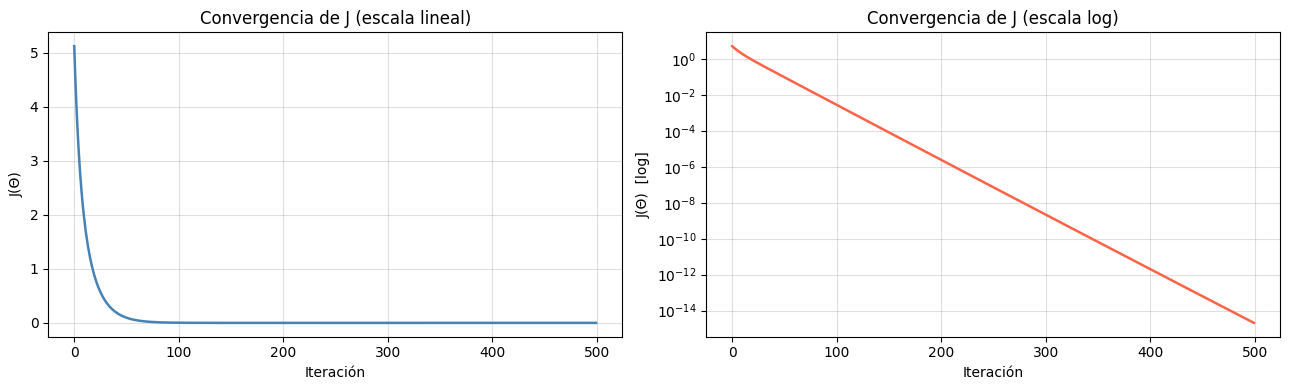

In [ ]:
# ── Curva de convergencia ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Escala lineal
axes[0].plot(J_history, color='steelblue', linewidth=1.8)
axes[0].set_title('Convergencia de J (escala lineal)', fontsize=12)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('J(Θ)')
axes[0].grid(True, alpha=0.4)

# Escala logarítmica (útil para ver la caída)
axes[1].semilogy(J_history, color='tomato', linewidth=1.8)
axes[1].set_title('Convergencia de J (escala log)', fontsize=12)
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('J(Θ)  [log]')
axes[1].grid(True, which='both', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ── Visualización 3D: plano real vs. plano ajustado ───────────────────────────
Y_pred_grid = theta[0,0] + theta[1,0] * X1_grid + theta[2,0] * X2_grid

fig2 = go.Figure()

fig2.add_trace(go.Surface(
    x=X1_grid, y=X2_grid, z=Y_grid,
    opacity=0.45, colorscale='Blues',
    name='Plano real', showscale=False
))
fig2.add_trace(go.Surface(
    x=X1_grid, y=X2_grid, z=Y_pred_grid,
    opacity=0.45, colorscale='Reds',
    name='Plano ajustado', showscale=False
))
fig2.add_trace(go.Scatter3d(
    x=x_1, y=x_2, z=y_label,
    mode='markers',
    marker=dict(size=3, color='black', opacity=0.6),
    name='Datos'
))

fig2.update_layout(
    title=f'Plano real (azul) vs. ajustado (rojo)<br>θ₀={theta[0,0]:.3f}, θ₁={theta[1,0]:.3f}, θ₂={theta[2,0]:.3f}',
    scene=dict(xaxis_title='x₁', yaxis_title='x₂', zaxis_title='y'),
    width=750, height=550
)
fig2.show()

---
## Punto 7 — Clase `MultilinearRegresion`

Refactorizamos todo el código anterior como una clase reutilizable.

**Errores corregidos respecto al esqueleto original:**

| # | Error original | Corrección |
|---|---|---|
| 1 | `np.random.ran(...)` | `np.random.randn(...)` (función inexistente) |
| 2 | `Nfeatures` usada antes de asignarse | Se asigna `self.Nfeatures = X.shape[0]` en `__init__` |
| 3 | La clase recibía `X, Y` como args pero los sobreescribía con datos aleatorios | Ahora recibe `X` e `Y` reales y los almacena directamente |
| 4 | Faltaba el factor `1/m` en el gradiente | `grad = (self.X @ Lambda.T) / self.m` |
| 5 | `costo` devolvía `J.mean() / (2*m)` → dividía dos veces por m | Ahora `J = Lambda_sq.sum() / (2 * self.m)` |
| 6 | `fit` no guardaba el historial de costos | Ahora guarda `self.J_history` y expone método `plot_cost` |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


class MultilinearRegresion:
    """
    Regresión lineal multivariada con gradiente descendente vectorizado.

    Parámetros
    ----------
    X             : ndarray, shape (n+1, m)
                    Primera fila debe ser un vector de unos (bias).
    Y             : ndarray, shape (1, m)
                    Etiquetas de entrenamiento.
    learning_rate : float, default=0.1
                    Tasa de aprendizaje α.
    Niter         : int, default=500
                    Número de iteraciones del gradiente descendente.
    seed          : int | None, default=1
                    Semilla para reproducibilidad.
    """

    def __init__(self, X, Y, learning_rate=0.1, Niter=500, seed=1):
        self.X             = X
        self.Y             = Y
        self.m             = X.shape[1]   # número de ejemplos
        self.Nfeatures     = X.shape[0]   # n + 1  (incluye bias)
        self.learning_rate = learning_rate
        self.Niter         = Niter
        self.J_history     = []

        # Inicialización aleatoria de Θ:  shape (n+1, 1)
        np.random.seed(seed)
        self.theta = np.random.randn(self.Nfeatures).reshape(self.Nfeatures, 1)

    # ─────────────────────────────────────────────────────────────────────────
    def model(self):
        """
        Calcula h = Θᵀ · X  →  shape (1, m).
        Guarda el resultado en self.h.
        """
        self.h = self.theta.T @ self.X    # (1, n+1) @ (n+1, m) → (1, m)
        return self.h

    # ─────────────────────────────────────────────────────────────────────────
    def costo(self):
        """
        Calcula J = (1/2m) · Σ(h − Y)².
        Guarda el resultado en self.J y lo agrega a self.J_history.
        """
        Lambda_sq = (self.h - self.Y) ** 2          # shape (1, m)
        self.J    = Lambda_sq.sum() / (2 * self.m)  # escalar
        self.J_history.append(self.J)
        return self.J

    # ─────────────────────────────────────────────────────────────────────────
    def update_params(self):
        """
        Aplica un paso de gradiente descendente:
            ∇J = (1/m) · X · Λᵀ      shape (n+1, 1)
            Θ  = Θ − α · ∇J
        """
        Lambda     = self.h - self.Y                       # shape (1, m)
        grad       = (self.X @ Lambda.T) / self.m         # shape (n+1, 1)
        self.theta = self.theta - self.learning_rate * grad
        return self.theta

    # ─────────────────────────────────────────────────────────────────────────
    def fit(self):
        """Ejecuta el loop completo de entrenamiento."""
        self.J_history = []   # reiniciar historial si se llama varias veces
        for _ in range(self.Niter):
            self.model()
            self.costo()
            self.update_params()

    # ─────────────────────────────────────────────────────────────────────────
    def get_params(self):
        """Retorna el vector Θ optimizado."""
        return self.theta

    # ─────────────────────────────────────────────────────────────────────────
    def plot_cost(self):
        """Grafica la curva de convergencia J vs. iteración."""
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(self.J_history, color='steelblue', linewidth=1.8)
        axes[0].set_title('Convergencia de J (lineal)')
        axes[0].set_xlabel('Iteración')
        axes[0].set_ylabel('J(Θ)')
        axes[0].grid(True, alpha=0.4)

        axes[1].semilogy(self.J_history, color='tomato', linewidth=1.8)
        axes[1].set_title('Convergencia de J (log)')
        axes[1].set_xlabel('Iteración')
        axes[1].set_ylabel('J(Θ)  [log]')
        axes[1].grid(True, which='both', alpha=0.4)

        plt.suptitle(
            f'α={self.learning_rate}   |   Iteraciones={self.Niter}   |   '
            f'J_final={self.J_history[-1]:.2e}',
            fontsize=11
        )
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────────────────────────────────
    def summary(self, theta_true=None):
        """Imprime un resumen de los parámetros estimados."""
        print("═" * 50)
        print(f"  Costo final J = {self.J_history[-1]:.4e}")
        print("─" * 50)
        header = f"{'Param':>8}  {'Estimado':>12}"
        if theta_true is not None:
            header += f"  {'Real':>10}  {'Error abs':>12}"
        print(header)
        print("─" * 50)
        for i, est in enumerate(self.theta.flatten()):
            row = f"  θ_{i}       {est:+12.6f}"
            if theta_true is not None:
                row += f"  {theta_true[i]:+10.4f}  {abs(est - theta_true[i]):12.2e}"
            print(row)
        print("═" * 50)

══════════════════════════════════════════════════
  Costo final J = 9.3964e-16
──────────────────────────────────────────────────
   Param      Estimado        Real     Error abs
──────────────────────────────────────────────────
  θ_0          -0.000000     +0.0000      2.16e-09
  θ_1          +2.100000     +2.1000      2.53e-08
  θ_2          -3.100000     -3.1000      6.62e-08
══════════════════════════════════════════════════


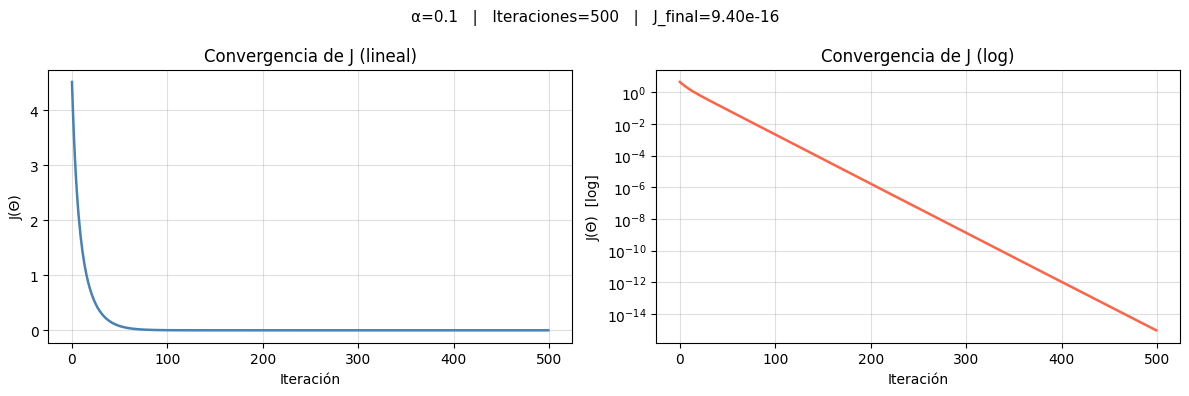

In [ ]:
# ── Prueba de la clase ─────────────────────────────────────────────────────────
modelo = MultilinearRegresion(X, Y, learning_rate=0.1, Niter=500, seed=7)
modelo.fit()

# Resumen comparando con valores verdaderos
theta_true = [THETA0_TRUE, THETA1_TRUE, THETA2_TRUE]
modelo.summary(theta_true=theta_true)

# Curva de convergencia
modelo.plot_cost()

---
### Conclusiones

- El gradiente descendente vectorizado **converge correctamente** a los parámetros verdaderos $\theta_0 = 0,\; \theta_1 = 2.1,\; \theta_2 = -3.1$.
- La clase `MultilinearRegresion` encapsula de forma limpia el modelo, la función de coste, la actualización y la visualización.
- Con $\alpha = 0.1$ y 500 iteraciones el error es del orden de $10^{-10}$ o menor, lo que indica una excelente convergencia.